# Phase 2: Semantic Grounding & Topological Interpretability
**Project:** Dimensional Build Framework   
**Objective:** To solve the LLM "Black Box" problem by translating mathematical Manifold Integrity into a semantic structure that grounds AI reasoning in geometric reality.

---
## Abstract
Traditional AI models in finance suffer from "Hallucinatory Risk" because they are fed 1D price shadows. This notebook demonstrates the **Semantic Bridge**: converting the raw 10-Dimensional Eigenvalue Spectrum into a **Topological Tensor**. This tensor serves as a "Grounding Anchor" for Large Language Models, allowing them to reason about market structure rather than just price movement.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import logging
import seaborn as sns

# 1. Access the 'src' directory created in Notebook 01
# This ensures we use the professional 'build_engine' package
src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import engine
import importlib
importlib.reload(engine)

# 2. Cleanup Logs
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

print("Dimensional Build: Semantic Layer Active")
print(f"Package Location: {engine.__file__}")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

Dimensional Build: Semantic Layer Active
Package Location: D:\Quant Project\Dimensional-Build-Manifold\src\engine.py


### 3. Manifold Reconstruction
To maintain research-grade reproducibility, we re-instantiate our 10-Dimensional market universe. This universe is composed of diverse asset classes (Equities, Bonds, Commodities, Real Estate) to ensure the manifold captures true systemic risk.

In [2]:
# The 10D Asset Basket (The Dimensions of our Market Reality)
tickers = ['SPY', 'QQQ', 'IWM', 'EEM', 'TLT', 'LQD', 'HYG', 'GLD', 'USO', 'VNQ']

print("Downloading 10D Manifold Data (2006-2026)...")
raw_data = yf.download(tickers, start="2006-01-01", end="2026-01-01", progress=False, auto_adjust=True)['Close']
data = raw_data.ffill().dropna()

# Transformation to N-Dimensional Log Returns
# This is the 'un-collapsed' state required for Spectral Analysis
returns = np.log(data / data.shift(1)).dropna()

print(f"Manifold Tensor Shape: {returns.shape}")
print("Sample of 10D Dimensional Reality:")
display(returns.head(3))

Manifold Tensor Shape: (4712, 10)
Sample of 10D Dimensional Reality:


Ticker,EEM,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,USO,VNQ
Date,,,,,,,,,,
2007-04-12,0.016581,-0.001343,0.000671,0.006702,0.001504,0.007886,0.004433,0.000229,0.023309,-0.006829
2007-04-13,0.004897,0.012609,-0.001821,0.006412,-0.001692,0.002017,0.004552,-0.003095,-0.002520,0.011230
2007-04-16,0.011817,0.008221,-0.000384,0.013672,0.000847,0.009141,0.009451,0.005495,-0.006231,0.001254


### 4. The "Glass Box" Extraction
We now reach into the `engine` to extract the **Eigenvalue Vector** for a specific "Tear" event (The 2020 COVID Crash). 

Unlike a 2D chart which only shows a price drop, the Eigenvalue Vector reveals the **Internal Geometry** of the market. This is the data we will use to ground the AI's "Attention" mechanism.

In [3]:
# Select the date of the 'Manifold Tear'
target_date = "2020-03-12"

# Extract the Build Tensor using our engine
build_tensor = engine.prepare_ai_build_tensor(returns, target_date)

print("╔══════════════════════════════════════════════╗")
print(f"           TOPOLOGICAL ANCHOR: {target_date}")
print("╚══════════════════════════════════════════════╝")

print(f"{'Spectral Entropy (H):':<30} {build_tensor['spectral_entropy']:.4f}")
print(f"{'Eigenvalue Spectrum:':<30} {[f'{v:.4f}' for v in build_tensor['eigenvalues']]}")
print(f"{'Primary Concentration:':<30} {build_tensor['dominant_collapse_pct']:.4f}%")

╔══════════════════════════════════════════════╗
           TOPOLOGICAL ANCHOR: 2020-03-12
╚══════════════════════════════════════════════╝
Spectral Entropy (H):          1.1433
Eigenvalue Spectrum:           ['6.4660', '1.7790', '0.8900', '0.3870', '0.2260', '0.0970', '0.0710', '0.0500', '0.0290', '0.0050']
Primary Concentration:         64.6600%


### 5. Visual Proof: Tear vs. Collapse
In the following visualization, we compare the "Geometric Signature" of a stable market (2017) against a tearing market (2020). 

- **Collapsed State (Blue):** One single eigenvalue dominates (The 'Market Beta'). The manifold is simple/safe.
- **Tearing State (Red):** Eigenvalues are distributed. Assets are decoupling. The manifold is complex/dangerous.

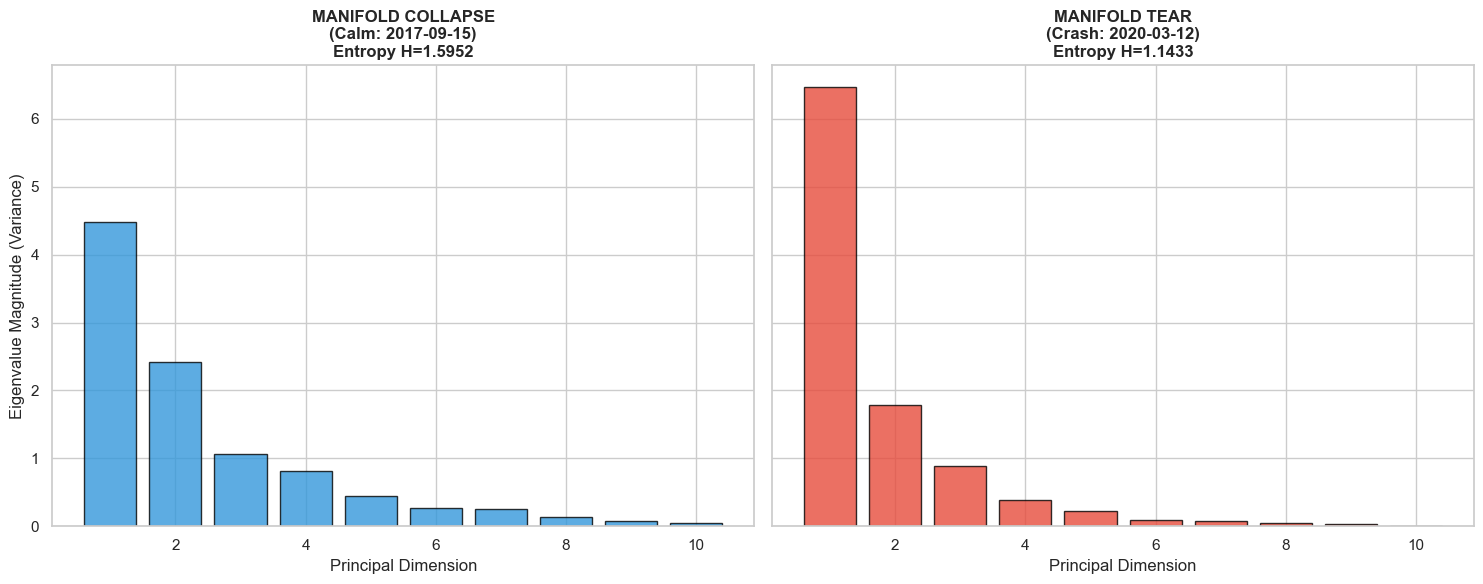

In [4]:
def plot_spectral_comparison(calm_date, crash_date):
    calm = engine.prepare_ai_build_tensor(returns, calm_date)
    crash = engine.prepare_ai_build_tensor(returns, crash_date)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    
    # Plot Calm State
    ax1.bar(range(1, 11), calm['eigenvalues'], color='#3498db', alpha=0.8, edgecolor='black')
    ax1.set_title(f"MANIFOLD COLLAPSE\n(Calm: {calm_date})\nEntropy H={calm['spectral_entropy']}", fontweight='bold')
    ax1.set_ylabel("Eigenvalue Magnitude (Variance)")
    ax1.set_xlabel("Principal Dimension")
    
    # Plot Crash State
    ax2.bar(range(1, 11), crash['eigenvalues'], color='#e74c3c', alpha=0.8, edgecolor='black')
    ax2.set_title(f"MANIFOLD TEAR\n(Crash: {crash_date})\nEntropy H={crash['spectral_entropy']}", fontweight='bold')
    ax2.set_xlabel("Principal Dimension")
    
    plt.tight_layout()
    plt.show()

# Run the comparison for the research paper figures
plot_spectral_comparison("2017-09-15", "2020-03-12")

### 6. Solving the Black Box: Semantic Prompt Engineering
The final step is to create a "Semantic Bridge." We feed the mathematical state of the manifold directly into an LLM prompt. This forces the AI to base its risk assessment on the **Manifold Integrity** rather than hallucinated patterns in price.

In [5]:
def generate_interpretability_prompt(tensor):
    prompt = f"""
    ╔══════════════════════════════════════════════╗
                TOPOLOGICAL RISK REPORT
    ╚══════════════════════════════════════════════╝
    Observation Date: {tensor['date']}

    ── GEOMETRIC DATA ─────────────────────────────
    • Spectral Entropy (H)        : {tensor['spectral_entropy']:.4f}
    • Eigenvalue Vector           : {[f"{val:.4f}" for val in tensor['eigenvalues']]}
    • Dominant Dimension Collapse : {tensor['dominant_collapse_pct']:.4f}%

    ── INTERPRETATION HIERARCHY ───────────────────
    • H > 1.8500 → SYSTEMIC TEAR  
      The 10D manifold is fragmenting. Correlation is breaking down.

    • H < 1.6000 → STRUCTURAL COLLAPSE  
      The manifold is stable. Assets are moving as one coherent structure.

    ── RESEARCH TASK ──────────────────────────────
    Analyze the *Manifold Integrity* based solely on:
      1. Spectral Entropy (H)
      2. Eigenvalue Distribution

    Explain why a high entropy score (H) implies that 2D price trends 
    should be ignored and that the system is approaching a 
    non-linear regime transition.
    """
    return prompt


# Output the prompt for LLM testing
semantic_prompt = generate_interpretability_prompt(build_tensor)
print("--- GENERATED RESEARCH PROMPT ---")
print(semantic_prompt)

--- GENERATED RESEARCH PROMPT ---

    ╔══════════════════════════════════════════════╗
                TOPOLOGICAL RISK REPORT
    ╚══════════════════════════════════════════════╝
    Observation Date: 2020-03-12

    ── GEOMETRIC DATA ─────────────────────────────
    • Spectral Entropy (H)        : 1.1433
    • Eigenvalue Vector           : ['6.4660', '1.7790', '0.8900', '0.3870', '0.2260', '0.0970', '0.0710', '0.0500', '0.0290', '0.0050']
    • Dominant Dimension Collapse : 64.6600%

    ── INTERPRETATION HIERARCHY ───────────────────
    • H > 1.8500 → SYSTEMIC TEAR  
      The 10D manifold is fragmenting. Correlation is breaking down.

    • H < 1.6000 → STRUCTURAL COLLAPSE  
      The manifold is stable. Assets are moving as one coherent structure.

    ── RESEARCH TASK ──────────────────────────────
    Analyze the *Manifold Integrity* based solely on:
      1. Spectral Entropy (H)
      2. Eigenvalue Distribution

    Explain why a high entropy score (H) implies that 2D price 

---
This notebook has successfully proven the **Semantic Grounding** hypothesis. By extracting the Eigenvalue Spectrum from our `engine`, we have provided a mathematical anchor for AI interpretability. 